# Module 4A — Clustering and How LLMs Work

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/notebooks/04_module4a_clustering.ipynb)

**ML/AI & GenAI Internship** · No API key needed. Each concept: examples → 5 exercises → quiz → tasks.

---

## What this notebook covers

Two concepts, each in the same shape: **📘 Examples → ✏️ 5 exercises → 🧠 Quiz → 🎯 Tasks.**

| # | Concept |
|---|---|
| 1 | Clustering — finding groups with no labels |
| 2 | What a Large Language Model actually is |

**No API key and no setup needed.** The Gemini API work is in [Module 4B](05_module4b_genai_api.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"

customers = pd.read_csv(BASE + "clustering/Mall_Customers.csv")
print("Loaded", len(customers), "customers")
customers.head()

Loaded 200 customers


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


---

# Concept 1 — Clustering: unsupervised learning

🧠 **Analogy: the box of old photographs.**

Someone hands you 500 unlabelled family photographs and asks you to organise them. Nobody tells you what the categories are.

You start laying them out and groups emerge on their own: beach photos, wedding photos, photos of one particular child growing up. **You did not decide the categories in advance — you discovered them from the photos themselves.**

That is clustering. Every model so far was given the right answers to learn from. **Clustering gets no answers at all, and finds structure anyway.**

> ⚠️ **One warning that follows directly.** Two different people organising the same box will produce different piles, and neither is "wrong". **Clustering has no answer key, so it has no accuracy score.** You judge it by whether the groups are *useful*, and that judgement is yours to make and defend.

### ✏️ Do this first — Activity: cluster the classroom

Before running any code, do it with people.

1. Everyone stands up
2. The instructor calls out two axes — say **"how far you travel to campus"** (left = near, right = far) and **"how early you wake up"** (front = early, back = late)
3. Everyone physically positions themselves accordingly
4. The instructor asks: **"Looking at this room, how many natural groups do you see?"**

**Discuss:**

- Did people agree on the number of groups? Usually not — some see 3, some see 5. **That disagreement is exactly the difficulty of choosing `k`.**
- Was anyone standing alone, far from everyone? That is an **outlier**, and K-Means will either drag a whole cluster towards them or give them their own.
- If the axes had been different — "hours of sleep" and "favourite subject" — would the groups be the same people? No. **Which features you choose determines which clusters you find.**

## 📘 Examples

### Example 1 — why scaling comes first

In [2]:
X = customers[["Annual Income (k$)", "Spending Score (1-100)"]]

print("BEFORE scaling — look at the ranges:")
print(X.describe().loc[["min", "max"]].round(1))

# KMeans measures DISTANCE. Income runs 15-137 and spending 1-99,
# so without scaling income would dominate every distance calculation
# purely because its numbers are bigger.
X_scaled = StandardScaler().fit_transform(X)

print("\nAFTER scaling — both now centred near 0 with a spread near 1:")
print(f"  means: {X_scaled.mean(axis=0).round(3)}")
print(f"  stds : {X_scaled.std(axis=0).round(3)}")

BEFORE scaling — look at the ranges:
     Annual Income (k$)  Spending Score (1-100)
min                15.0                     1.0
max               137.0                    99.0

AFTER scaling — both now centred near 0 with a spread near 1:
  means: [-0. -0.]
  stds : [1. 1.]


### Example 2 — choosing k with two guides

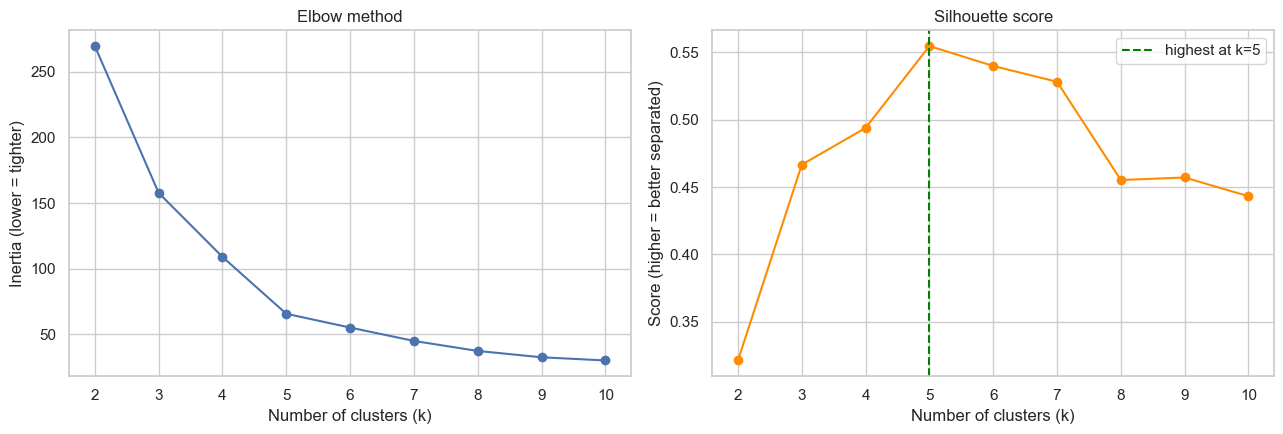

In [3]:
# There is no correct k. Use two guides and your own judgement.
#   Inertia    - how TIGHT the clusters are. Always falls as k rises,
#                so look for the "elbow" where it stops falling steeply.
#   Silhouette - how well SEPARATED they are. Higher is better.

inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_range, inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter)")

axes[1].plot(k_range, silhouettes, marker="o", color="darkorange")
best_k = k_range[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="green", linestyle="--", label=f"highest at k={best_k}")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score (higher = better separated)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 How to read this chart — Elbow and silhouette charts

| What you are looking at | What it means |
|---|---|
| **Elbow: the y-axis (inertia)** | Total distance from each point to its cluster centre. Lower = tighter clusters |
| **Elbow: why it always falls** | More clusters always means tighter ones. At k = n every point is its own cluster, inertia 0 |
| **Elbow: the bend** | Where the steep drop turns into a gentle slope. Past that, extra clusters buy you little |
| **Silhouette: the y-axis** | How well separated the clusters are, from −1 to +1 |
| **Silhouette above 0.5** | Good separation. Below 0.25, the clusters barely exist |
| **Silhouette: the peak** | The mathematically best-separated k |
| **When the two disagree** | Common. Neither is authoritative — pick the k you can *explain* |

> **In one sentence:** The elbow tells you where extra clusters stop paying off and the silhouette tells you which k separates best — but the final choice is yours to justify in business terms, not theirs to dictate.

### Example 3 — fit, then interpret (the step everyone skips)

In [4]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
customers["segment"] = kmeans.fit_predict(X_scaled)

# A cluster NUMBER is useless to anyone who has to act on it.
# The profile table is what turns it into something a manager can use.
profiles = customers.groupby("segment")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
profiles["count"] = customers["segment"].value_counts().sort_index()

print("Average profile of each segment:")
print(profiles)

Average profile of each segment:
          Age  Annual Income (k$)  Spending Score (1-100)  count
segment                                                         
0        42.7                55.3                    49.5     81
1        32.7                86.5                    82.1     39
2        25.3                25.7                    79.4     22
3        41.1                88.2                    17.1     35
4        45.2                26.3                    20.9     23


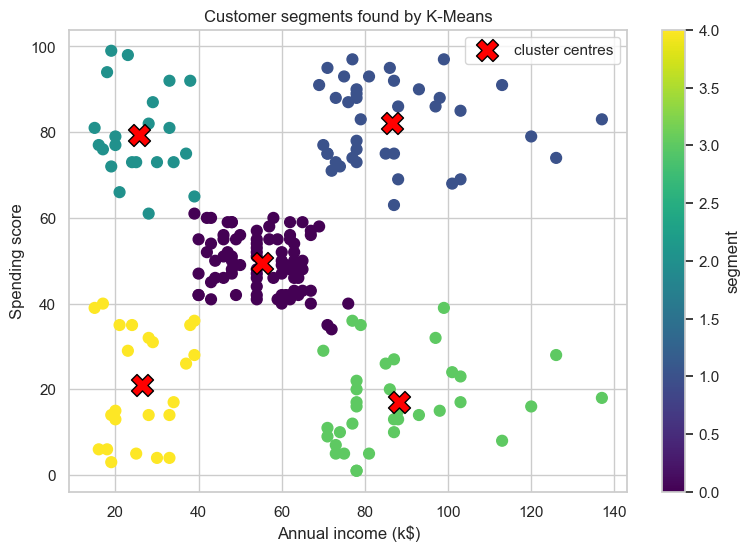

In [5]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"],
                      c=customers["segment"], cmap="viridis", s=60)
centres = StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_)
plt.scatter(centres[:, 0], centres[:, 1], c="red", marker="X", s=250,
            edgecolors="black", label="cluster centres")
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score")
plt.title("Customer segments found by K-Means")
plt.colorbar(scatter, label="segment")
plt.legend()
plt.show()

### 📊 How to read this chart — Cluster scatter plot

| What you are looking at | What it means |
|---|---|
| **Each dot** | One customer, positioned by their income and spending |
| **Each colour** | One cluster the algorithm found |
| **The red X markers** | Cluster centres — the 'average customer' of each group |
| **Well-separated colour blobs** | ✅ The clusters are real and distinct |
| **Colours bleeding into each other** | ⚠️ The boundary is arbitrary; those customers could go either way |
| **A dot far from every centre** | An outlier. It was forced into a cluster it does not really belong to |
| **A corner of the chart with its own colour** | A genuinely distinct group — usually your most actionable segment |

> **In one sentence:** Look at the four corners: high-income/high-spending and high-income/low-spending are completely different customers, and the corner groups are almost always the ones worth acting on.

### ✏️ Name every segment

**This is the step everyone skips.** A cluster number is meaningless to whoever has to act on it.

Look at the profile table and give each segment a **business name**:

| Segment | Income | Spending | Your name for them |
|---|---|---|---|
| 0 | | | |
| 1 | | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |

**✅ Check yourself:** could you explain your chosen k to a shop manager who knows no maths? *"The silhouette score was highest"* is not an explanation. *"We found five kinds of customer, and here is what each one is like"* is.

## ✏️ Practice now — Clustering

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Re-run K-Means with `k=3`. Print the profile table. Are the groups still distinct?

**2.** Re-run with `k=8`. Do any segments now have fewer than 10 customers? Why is that a problem?

**3.** Add `Age` as a third clustering feature. Do the segments change meaningfully?

**4.** Compute the silhouette score for k=3, k=5 and k=8. Which is highest?

**5.** Cluster on `Age` and `Spending Score` instead of income. Do you get different customers grouped together?

In [6]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
customers["seg3"] = km3.fit_predict(X_scaled)
print(customers.groupby("seg3")[["Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1))

# 2
km8 = KMeans(n_clusters=8, random_state=42, n_init=10)
customers["seg8"] = km8.fit_predict(X_scaled)
print(customers["seg8"].value_counts().sort_index())
# Tiny segments are unreliable - an "average" built on 6 people is not a finding.

# 3
X3 = customers[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
X3s = StandardScaler().fit_transform(X3)
customers["seg_age"] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X3s)
print(customers.groupby("seg_age")[X3.columns.tolist()].mean().round(1))

# 4
for k in [3, 5, 8]:
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(k, round(silhouette_score(X_scaled, lab), 4))

# 5
Xa = StandardScaler().fit_transform(customers[["Age", "Spending Score (1-100)"]])
customers["seg_as"] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(Xa)
print(pd.crosstab(customers["segment"], customers["seg_as"]))
# Different features -> different groups. Neither is "correct".
```

</details>

## 🧠 Quick quiz — Clustering

Answer all five from memory. No scrolling back.

**Q1.** Why does clustering have no accuracy score?

**Q2.** Why must you scale features before K-Means?

**Q3.** Your elbow chart suggests k=4 and your silhouette suggests k=6. Which do you use?

**Q4.** You cluster with k=8 and one segment has 6 customers. What is the problem?

**Q5.** You clustered on income and spending. A colleague clusters the same customers on age and spending and gets different groups. Who is right?

<details>
<summary><b>Answers</b></summary>

**A1.** There is no answer key — nobody labelled the 'correct' groups, so there is nothing to be accurate against. You judge clustering by whether the groups are **useful and defensible**, using guides like silhouette, and by whether you can name them.

**A2.** K-Means measures **distance**. If income runs 15–137 and spending runs 1–99, income dominates every distance calculation purely because its numbers are bigger — so the clusters would be driven almost entirely by income.

**A3.** Neither is authoritative. Look at both profile tables and pick the k you can **explain in business terms**. If six segments produce two you cannot tell apart, four is the better answer regardless of the score.

**A4.** An 'average customer' computed from 6 people is not a finding — it is noise. Tiny segments are unstable: re-run with a different seed and those 6 people scatter. Prefer a smaller k where every segment is large enough to act on.

**A5.** **Both, and neither.** Clustering finds structure in the features you give it. Different features reveal different structure. The right question is not which is correct but which is more *useful* for the decision you are about to make.

</details>

## 🎯 Tasks — Clustering

Longer work. Do these after the session, in your own time.

### Task 1: The segmentation report

Produce a one-page customer segmentation report a retail manager could act on.

Required:
1. Your chosen k, with the elbow and silhouette evidence
2. **A justification of k in business language**, not statistical language
3. The profile table
4. The scatter plot with centres marked
5. **A memorable name and a one-sentence description for every segment**
6. **One concrete marketing action per segment**
7. One paragraph on what this analysis *cannot* tell you

Point 7 matters: clustering found groups in two columns. It knows nothing about why those customers behave that way.

### Task 2: Stability check

How stable are your segments really?

1. Run K-Means five times with different `random_state` values
2. For each run, record the size of each segment
3. Do the same customers stay together?
4. Now do the same with `n_init=1` instead of `n_init=10`. Is it more or less stable?

Write three sentences on what `n_init` does and why the default matters.

**The question this answers:** if your segments change every time you run the code, can you build a marketing campaign on them?

### Task 3: Cluster a different dataset

Apply clustering to `classification/diabetes_prediction_dataset.csv` — **ignoring the `diabetes` label entirely**.

1. Choose sensible numeric features and scale them
2. Choose k with evidence
3. Profile and name your clusters
4. **Now** compare your clusters against the real `diabetes` column with `pd.crosstab`
5. Did any cluster happen to capture mostly diabetic patients?

> This is a nice demonstration that unsupervised learning can *discover* structure that turns out to be meaningful — but you only knew it was meaningful because you had labels to check against afterwards.

---

# Concept 2 — What a Large Language Model actually is

🧠 **Analogy: the world's most well-read autocomplete.**

Open the messaging app on your phone and type "I will be". Look at the three words it suggests. Keep tapping the middle suggestion, over and over. You will get a sentence — grammatical, plausible, and completely generic.

Your phone learned those suggestions from the messages you and millions of others have typed.

**An LLM is that, scaled up almost unimaginably.** Instead of your text messages, it learned from a substantial fraction of everything ever written. Instead of suggesting three words, it weighs a hundred thousand possible next chunks with a probability on each.

**Nothing else changed. It is still autocomplete.** Every impressive thing an LLM does — writing code, explaining photosynthesis, translating Tamil — comes out of doing autocomplete extraordinarily well.

### Why this analogy explains the two confusing things

**"Why does it make things up?"**
Your phone does not check whether "I will be late" is true. It suggests what is *likely to come next*. An LLM does the same. Ask it for a citation and it produces text shaped exactly like a real citation — right author style, right journal-sounding name, right year format — because that is what is probable there. **Whether the paper exists was never part of the calculation.** That is a **hallucination**, and it is not a bug; it is what the machine does.

**"Why does it forget what I just said?"**
Your phone does not remember yesterday's conversation. Neither does an LLM between calls. Each request starts blank. If a chatbot appears to remember, it is because the *program* is quietly re-sending the whole conversation every single time.

### ✏️ Do this first — Activity: be the language model

Five minutes on paper, before any code. It makes everything afterwards obvious.

**Round 1 — the easy one.** On the board:

```text
"The capital of France is ___"
```

Everyone shouts the next word. Almost certainly unanimous: *Paris*. Write up the "probabilities":

```text
Paris        ~95%
a            ~2%
located      ~1%
```

**Round 2 — the hard one.**

```text
"The weather today is really ___"
```

Now the class splits: *hot, cold, nice, bad, humid, unpredictable*. Count the votes and write the top five with percentages.

**Round 3 — build a sentence together.** Start with one word and go round the class. Each person adds **only** the single word they think most likely follows.

**The debrief — this is the important part:**

1. **Round 1 vs Round 2.** In Round 1 almost everyone agreed; in Round 2 you scattered. **That difference is exactly what `temperature` controls.** At temperature 0 the model always takes the top choice. At temperature 1 it samples from the whole spread.
2. **In Round 3, did anyone know what the sentence would be?** No. Each person saw only what came before and added one likely word. **The sentence had no author and no plan.** That is precisely how an LLM generates a paragraph.
3. **Did anyone check whether the sentence was true?** No. You were each choosing what *sounds right next*, not what is correct. **Now you understand hallucination from the inside.**

## 📘 Examples

### Example 1 — count the tokens yourself

In [7]:
# Models do not read words. They read TOKENS - chunks roughly 3/4 of a word.
# This simple approximation is close enough to build intuition.

samples = ["cat", "unbelievable", "internationalisation",
           "Thiruvananthapuram", "AI", "machine learning is fun"]

print(f"{'text':<26}{'chars':>7}{'~tokens':>9}")
print("-" * 42)
for text in samples:
    approx = max(1, round(len(text) / 4))
    print(f"{text:<26}{len(text):>7}{approx:>9}")

print("\nRule of thumb: 1 token ~ 4 characters ~ 3/4 of a word.")
print("Check the real numbers at platform.openai.com/tokenizer")

text                        chars  ~tokens
------------------------------------------
cat                             3        1
unbelievable                   12        3
internationalisation           20        5
Thiruvananthapuram             18        4
AI                              2        1
machine learning is fun        23        6

Rule of thumb: 1 token ~ 4 characters ~ 3/4 of a word.
Check the real numbers at platform.openai.com/tokenizer


**What you will notice at a real tokenizer:** common short words are one token. Long or unusual words split into several. Names and non-English words split the most. An emoji can cost several tokens on its own.

**Why you should care:**

- You are **billed per token**, and the context window is measured in tokens
- A prompt full of long unusual names costs meaningfully more than the same length of ordinary English
- It explains a classic puzzle: ask a model how many `r`s are in "strawberry" and it often gets it wrong, **because it never saw the individual letters** — it saw two or three chunks

### Example 2 — a tiny next-token predictor you can run locally

In [8]:
# A word-level Markov chain: the crudest possible language model.
# It only knows "which word followed which" in the text you give it.
# The mechanism is the same idea as an LLM, roughly a billion times simpler.

from collections import defaultdict
import random

TEXT = """
machine learning is a method where computers learn patterns from data
machine learning is used in many applications
deep learning is a kind of machine learning
learning from data is what makes machine learning useful
"""

words = TEXT.split()
follows = defaultdict(list)
for current, nxt in zip(words, words[1:]):
    follows[current].append(nxt)

# What can follow the word "machine"?
print("After 'machine' the model has seen:", follows["machine"])
print("After 'learning':", follows["learning"])

random.seed(42)
word, sentence = "machine", ["machine"]
for _ in range(10):
    if word not in follows:
        break
    word = random.choice(follows[word])     # pick a plausible next word
    sentence.append(word)

print("\nGenerated:", " ".join(sentence))
print("\nGrammatical? Mostly. Meaningful? Not necessarily.")
print("That gap between 'sounds right' and 'is right' IS hallucination.")

After 'machine' the model has seen: ['learning', 'learning', 'learning', 'learning']
After 'learning': ['is', 'is', 'is', 'learning', 'from', 'useful']

Generated: machine learning is a method where computers learn patterns from data

Grammatical? Mostly. Meaningful? Not necessarily.
That gap between 'sounds right' and 'is right' IS hallucination.


### Example 3 — temperature, without any API

In [9]:
# Temperature reshapes a probability distribution BEFORE sampling.
# Low temperature sharpens it; high temperature flattens it.

def apply_temperature(probs, temperature):
    probs = np.asarray(probs, dtype=float)
    if temperature == 0:                    # always take the top choice
        out = np.zeros_like(probs); out[probs.argmax()] = 1.0
        return out
    logits = np.log(probs + 1e-12) / temperature
    exp = np.exp(logits - logits.max())
    return exp / exp.sum()

candidates = ["hot", "cold", "nice", "humid", "unpredictable"]
original = [0.40, 0.25, 0.20, 0.10, 0.05]

print(f"{'token':<16}" + "".join(f"{f'T={t}':>10}" for t in [0.0, 0.5, 1.0, 2.0]))
print("-" * 56)
for i, token in enumerate(candidates):
    row = "".join(f"{apply_temperature(original, t)[i]:>10.3f}"
                  for t in [0.0, 0.5, 1.0, 2.0])
    print(f"{token:<16}{row}")

token                T=0.0     T=0.5     T=1.0     T=2.0
--------------------------------------------------------
hot                  1.000     0.582     0.400     0.298
cold                 0.000     0.227     0.250     0.236
nice                 0.000     0.145     0.200     0.211
humid                0.000     0.036     0.100     0.149
unpredictable        0.000     0.009     0.050     0.105


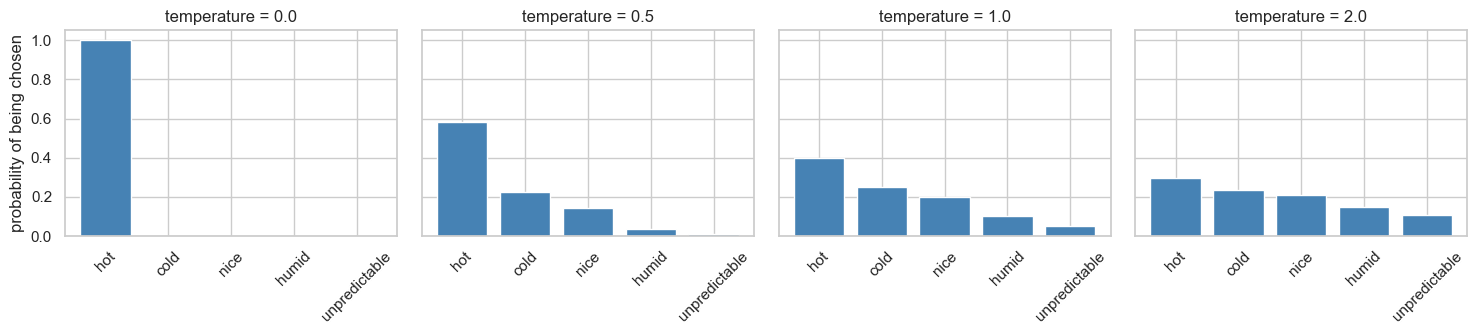

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, t in zip(axes, [0.0, 0.5, 1.0, 2.0]):
    ax.bar(candidates, apply_temperature(original, t), color="steelblue")
    ax.set_title(f"temperature = {t}")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("probability of being chosen")
plt.tight_layout()
plt.show()

### 📊 How to read this chart — Temperature effect on token probabilities

| What you are looking at | What it means |
|---|---|
| **Each bar** | How likely that word is to be chosen as the next token |
| **T = 0.0** | One bar at 1.0, all others at zero. **Always the same output** |
| **T = 0.5** | The top choice is sharpened; unlikely words nearly vanish. Safe and focused |
| **T = 1.0** | The model's own probabilities, untouched. Balanced |
| **T = 2.0** | Bars flattened towards equal. Even 'unpredictable' becomes a real possibility |
| **Bars becoming more equal as T rises** | That flattening **is** creativity — and also **is** the risk of nonsense |

> **In one sentence:** Low temperature makes the model repeat its single best guess every time; high temperature levels the playing field so unlikely words get a real chance — which is exactly why creative writing wants a high value and invoice extraction wants zero.

## ✏️ Practice now — How LLMs work

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Using `apply_temperature`, what probability does 'hot' get at T=0.1? And at T=5.0?

**2.** At which temperature does 'unpredictable' first exceed 10% probability?

**3.** Feed the Markov model a different `TEXT` (a paragraph from this notebook) and generate a sentence.

**4.** In the Markov model, print how many different words can follow 'is'. What does a longer list mean?

**5.** Estimate the token count of a 500-word essay. At $0.30 per million tokens, what would 1,000 such essays cost?

In [11]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1
print("T=0.1:", apply_temperature(original, 0.1)[0].round(4))
print("T=5.0:", apply_temperature(original, 5.0)[0].round(4))

# 2
for t in [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    p = apply_temperature(original, t)[4]
    print(f"T={t}: unpredictable = {p:.3f}")

# 3  Replace TEXT with your own paragraph and re-run the Markov cell.

# 4
print("words that can follow 'is':", follows["is"])
# A longer list means MORE uncertainty at that point - the model has more
# plausible continuations, so its output there is less predictable.

# 5
words_total = 500 * 1000
tokens = words_total / 0.75          # ~0.75 words per token
print(f"{tokens:,.0f} tokens -> ${tokens / 1_000_000 * 0.30:.2f}")
```

</details>

## 🧠 Quick quiz — How LLMs work

Answer all five from memory. No scrolling back.

**Q1.** Explain in one sentence, *in terms of how it works*, why an LLM hallucinates.

**Q2.** What is a token, and why does it matter to you practically?

**Q3.** Why does a model often miscount the letters in 'strawberry'?

**Q4.** What does `temperature = 0` actually do to the probability distribution?

**Q5.** Your chatbot forgets the previous question. Why, and what fixes it?

<details>
<summary><b>Answers</b></summary>

**A1.** It predicts what text is **probable** next, not what is **true** — it has no database of facts to check against, so a plausible-sounding fabricated citation is exactly as likely to be produced as a real one. 'It makes mistakes' is not an answer; the mechanism is.

**A2.** A chunk of text, roughly ¾ of a word. It matters because you are **billed per token** and the context window is measured in tokens — so a long prompt costs money on every single call.

**A3.** Because it never saw the individual letters. It saw two or three **tokens**. Counting characters requires information the tokenizer already threw away.

**A4.** It collapses it: the single most probable token gets probability 1.0 and everything else gets 0. There is no randomness left, so the same prompt gives the same output every time.

**A5.** The API is **stateless** — each call starts blank. The fix is in your program, not the model: re-send the conversation history with every request. **Memory is a feature your program provides, not a property of the model.**

</details>

## 🎯 Tasks — How LLMs work

Longer work. Do these after the session, in your own time.

### Task 1: Build a better Markov model

Extend the word-level Markov chain into a **bigram** model: instead of "which word follows this word", use "which word follows this **pair** of words".

1. Build it on a longer text (paste several paragraphs)
2. Generate 5 sentences from each model and compare
3. Which produces more coherent text? Why?
4. What happens when your bigram model hits a pair it has never seen?

**Then answer the big one:** an LLM is essentially this idea with a context of thousands of tokens instead of two, and learned weights instead of counts. **What does that extra context buy it?**

### Task 2: The token budget

You are building an app that summarises documents. Work out its economics.

1. Estimate tokens for a 2,000-word document
2. Your prompt template adds 150 words of instructions
3. The summary output is about 200 words
4. Compute the total tokens for **one** call
5. At $0.30 per million input tokens and $2.50 per million output tokens, cost per call?
6. Cost for 10,000 documents per month?
7. **Now: how would you halve that cost without changing the model?**

<details><summary>Hint for 7</summary>
Shorten the prompt template, batch related documents, cache repeated instructions, or filter cheaply first so the LLM only sees documents that actually need summarising.
</details>

### Task 3: Predict the next word — the human study

Run Activity Round 2 with **ten people** on five different sentence starts.

1. Record every vote
2. Compute the actual probability distribution for each sentence
3. Which sentence had the sharpest distribution? Which the flattest?
4. Relate flatness back to temperature: which sentences would an LLM answer identically every time, and which would vary?

**Write two sentences on what this tells you about when to trust an LLM's answer.**

---
## What next

| | |
|---|---|
| **Previous** | [Module 3 — Model improvement](03_module3_model_improvement.ipynb) |
| **Next** | [Module 4B — Generative AI and the Gemini API](05_module4b_genai_api.ipynb) |
| **Handbook** | [Module 4 chapter](../student-handbook.md#module-4--deep-learning-clustering-and-generative-ai) |
| **More practice** | [exercises-assignments.md](../exercises-assignments.md) |